# 02 — 4ft-Miner: Úloha 2
## Nováčci na road vs. trail závodech
### 4IZ503 Projektový seminář — Ultra Marathon Running

**Výzkumná otázka:**
Ztrácejí nováčci (první start) na trail závodech výrazně více než na silničních závodech?
Hypotéza: trail závody penalizují nezkušenost mnohem více — kvůli nárokům na orientaci, technickou výbavu, tempo a strategii výstupu/sestupu.

**Ante:** `experience_cat(nováček) ∧ surface(trail)`
**Succ:** `speed_cat(pomalý)`

**Srovnávací pravidlo:** `experience_cat(nováček) ∧ surface(road) ⟹ speed_cat(pomalý)`

**Business interpretace:** Závodům s trail povrchem se vyplatí nabízet beginner waves nebo kratší varianty — jinak odradí potenciální opakované zákazníky.

**Limitace:** Analýza pracuje pouze se záznamy, které mají definovaný povrch (`surface` in `('trail', 'road')`), a kde máme kompletní údaje o zkušenostech a rychlosti.

> ⚠️ **Metodická poznámka:** `speed_cat` je přepočítán *per event* (ne per distance_cat)
> v rámci každého konkrétního závodu (`event_name`) zvlášť, aby bylo srovnání běžců férové — každý závod má přesně ~33 % pomalých, středních a rychlých závodníků.


## 1. Import a načtení dat

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = Path('../data/processed')
df = pd.read_parquet(DATA_DIR / 'ultra_clean.parquet')
print(f"Načteno: {len(df):,} řádků")


Načteno: 6,877,109 řádků


## 2. Příprava dat

In [2]:
# Filtr: road a trail závody + kompletní záznamy
df_filtered = df[
    df['surface'].isin(['trail', 'road']) &
    df['surface'].notna() &
    df['speed_cat'].notna() &
    df['experience_cat'].notna() &
    df['avg_speed'].notna()
].copy()

print(f"Záznamy s road/trail povrchem: {len(df_filtered):,}")
print(f"\nRozložení podle povrchu v původním datasetu:")
print(df_filtered['surface'].value_counts())


Záznamy s road/trail povrchem: 920,632

Rozložení podle povrchu v původním datasetu:
surface
road     684152
trail    236480
Name: count, dtype: int64


In [3]:
# ⚠️ Přepočet speed_cat PER EVENT — férové srovnání
# (původní speed_cat je per distance_cat, což zkresluje výsledky
#  protože různé závody mají různou obtížnost a podmínky)
def assign_speed_cat_per_event(group):
    q33 = group['avg_speed'].quantile(0.33)
    q67 = group['avg_speed'].quantile(0.67)
    conditions = [
        group['avg_speed'] <= q33,
        group['avg_speed'] <= q67,
        group['avg_speed'] >  q67,
    ]
    choices = ['pomalý', 'střední', 'rychlý']
    return pd.Series(np.select(conditions, choices, default=None), index=group.index)

print("Přepočítávám speed_cat per event...")
df_filtered['speed_cat_event'] = df_filtered.groupby('event_name', group_keys=False).apply(
    assign_speed_cat_per_event
)

# Odstranění případných chybějících hodnot po přepočtu
df_filtered = df_filtered[df_filtered['speed_cat_event'].notna()].copy()
print(f"Finální dataset po přepočtu: {len(df_filtered):,} závodníků")
print(f"\nRozložení speed_cat_event (ověření ~33/33/33):")
print((df_filtered['speed_cat_event'].value_counts() / len(df_filtered) * 100).round(1))


Přepočítávám speed_cat per event...


Finální dataset po přepočtu: 920,632 závodníků

Rozložení speed_cat_event (ověření ~33/33/33):
speed_cat_event
střední    34.0
pomalý     33.0
rychlý     33.0
Name: count, dtype: float64


## 3. Hlavní analýza: podíl pomalých závodníků dle zkušeností a povrchu

In [4]:
# Pivot tabulka: podíl 'pomalý' (%) podle experience_cat a surface
pivot = df_filtered.groupby(['experience_cat', 'surface'])['speed_cat_event'].apply(
    lambda x: (x == 'pomalý').sum() / len(x) * 100
).unstack()

# Srovnáme řádky a sloupce do logického pořadí
pivot = pivot.reindex(index=['nováček', 'zkušený', 'veterán'], columns=['road', 'trail'])

print("Podíl závodníků v kategorii 'pomalý' (%) dle zkušeností a povrchu:")
print(pivot.round(1))

# Počty pro transparentnost
counts = df_filtered.groupby(['experience_cat', 'surface']).size().unstack()
counts = counts.reindex(index=['nováček', 'zkušený', 'veterán'], columns=['road', 'trail'])
print("\nPočty závodníků v každé buňce:")
print(counts)


Podíl závodníků v kategorii 'pomalý' (%) dle zkušeností a povrchu:
surface         road  trail
experience_cat             
nováček         42.3   39.6
zkušený         32.0   32.1
veterán         30.5   30.6

Počty závodníků v každé buňce:
surface           road   trail
experience_cat                
nováček         118868   50119
zkušený         220108   82238
veterán         345176  104123


In [5]:
# Relativní nevýhoda nováčků oproti veteránům
rel_disadv = pivot.loc['nováček'] - pivot.loc['veterán']

print("Relativní nevýhoda nováčků oproti veteránům (v procentních bodech - pb):")
print("(kladné = nováčci mají o tolik pb vyšší podíl pomalých běžců než veteráni)")
for surf in ['road', 'trail']:
    print(f"  {surf.capitalize():5s}: +{rel_disadv[surf]:.2f} pb")


Relativní nevýhoda nováčků oproti veteránům (v procentních bodech - pb):
(kladné = nováčci mají o tolik pb vyšší podíl pomalých běžců než veteráni)
  Road : +11.84 pb
  Trail: +8.99 pb


## 4. Vizualizace

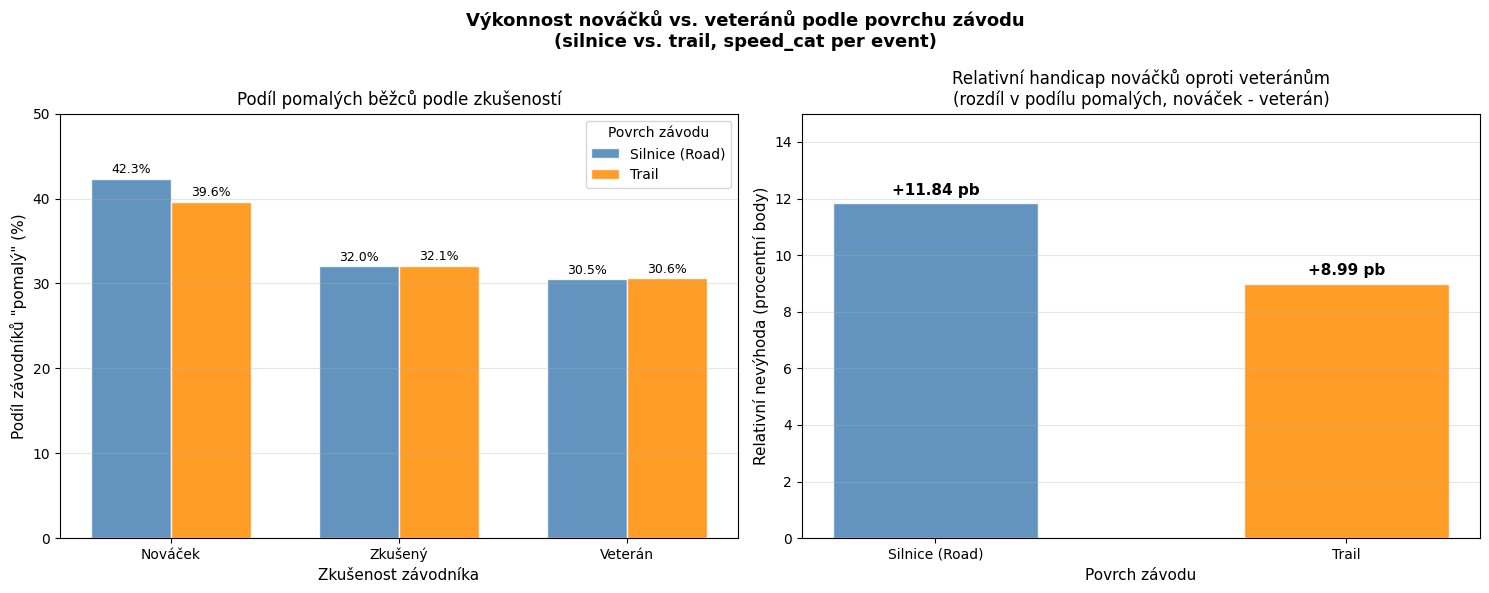

Graf uložen.


In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Výkonnost nováčků vs. veteránů podle povrchu závodu\n(silnice vs. trail, speed_cat per event)',
             fontsize=13, fontweight='bold')

# Graf 1 — absolutní podíl pomalých
exp_order = ['nováček', 'zkušený', 'veterán']
x = np.arange(len(exp_order))
width = 0.35

# Barvy pro silnici a trail
colors = {'road': 'steelblue', 'trail': 'darkorange'}

bars_road = ax1.bar(x - width/2, [pivot.loc[exp, 'road'] for exp in exp_order], width,
                     label='Silnice (Road)', color=colors['road'], alpha=0.85, edgecolor='white')
bars_trail = ax1.bar(x + width/2, [pivot.loc[exp, 'trail'] for exp in exp_order], width,
                      label='Trail', color=colors['trail'], alpha=0.85, edgecolor='white')

# Popisky na sloupcích
for bars in [bars_road, bars_trail]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

ax1.set_xlabel('Zkušenost závodníka', fontsize=11)
ax1.set_ylabel('Podíl závodníků "pomalý" (%)', fontsize=11)
ax1.set_title('Podíl pomalých běžců podle zkušeností', fontsize=12)
ax1.set_xticks(x)
ax1.set_xticklabels([exp.capitalize() for exp in exp_order], fontsize=10)
ax1.legend(title='Povrch závodu', fontsize=10)
ax1.grid(axis='y', alpha=0.3)
ax1.set_ylim(0, 50)

# Graf 2 — relativní nevýhoda nováčků vs. veteránů
bars_rel = ax2.bar(['Silnice (Road)', 'Trail'], [rel_disadv['road'], rel_disadv['trail']], 
                    color=[colors['road'], colors['trail']], alpha=0.85, edgecolor='white', width=0.5)

for bar in bars_rel:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.2,
             f'+{h:.2f} pb', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax2.set_xlabel('Povrch závodu', fontsize=11)
ax2.set_ylabel('Relativní nevýhoda (procentní body)', fontsize=11)
ax2.set_title('Relativní handicap nováčků oproti veteránům\n(rozdíl v podílu pomalých, nováček - veterán)', fontsize=12)
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 15)

plt.tight_layout()
plt.savefig(DATA_DIR / '02_novacci_road_vs_trail.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graf uložen.")


### 📊 Interpretace grafů

**Graf vlevo — Podíl pomalých běžců podle zkušeností:**

Sledováním trendu od nováčků k veteránům vidíme jasné potvrzení, že s rostoucí zkušeností klesá podíl pomalých běžců. 
- Na **silnici (road)** klesá podíl pomalých ze **42.3 %** (nováčci) na **32.0 %** (zkušení) a dále na **30.5 %** (veteráni).
- Na **trailu** klesá podíl pomalých ze **39.6 %** (nováčci) na **32.1 %** (zkušení) a dále na **30.6 %** (veteráni).

Nováčci jsou na obou površích výrazně častěji zastoupeni v nejpomalejší třetině startovního pole než zkušení běžci a veteráni.

**Graf vpravo — Relativní handicap nováčků oproti veteránům:**

Tento graf přináší překvapivé zjištění, které **vyvrací původní hypotézu**:
- Původní předpoklad byl, že trail penalizuje nezkušenost více než silnice (kvůli náročnému terénu, navigaci a výbavě).
- Data však ukazují opak: **relativní nevýhoda nováčků oproti veteránům je větší na silnici (+11.84 pb) než na trailu (+8.99 pb)**.

**Proč tomu tak je?**
1. **Efekt selekce (bariéra vstupu):** Na silniční ultramaraton se může přihlásit prakticky kdokoli jako na svůj "první závod" (nováček), což vede k vysoké variabilitě kondice a nepřipravenosti. Naopak ti, kteří běží svůj první oficiální ultra závod na trailu, jsou již často zkušení běžci (např. mají naběháno mnoho silničních maratonů či trailových tréninků, které se v databázi ultramaratonů neobjevují jako "předchozí start").
2. **Fyzikální a terénní limity trailu:** Technický terén (bláto, kameny, prudké kopce) přirozeně omezuje maximální rychlost všech běžců — i ti nejzkušenější musí v technických pasážích zpomalit. Silnice naopak přeje plynulému běhu, kde perfektní pacing a vytrvalost (kterou mají veteráni skvěle zvládnutou) vytváří obrovské výkonnostní rozdíly.


## 5. Statistická validace

In [7]:
print("Chi-square testy nezávislosti: závisí speed_cat_event na experience_cat?\n")

for surface in ['road', 'trail']:
    subset = df_filtered[df_filtered['surface'] == surface]
    ct = pd.crosstab(subset['experience_cat'], subset['speed_cat_event'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {surface.upper():5s}: chi2={chi2:.2f}, p={p:.2e} {sig}  (n={len(subset):,})")

print("\nLegenda: *** p<0.001  ** p<0.01  * p<0.05  ns = nesignifikantní")


Chi-square testy nezávislosti: závisí speed_cat_event na experience_cat?



  ROAD : chi2=8038.30, p=0.00e+00 ***  (n=684,152)
  TRAIL: chi2=2228.90, p=0.00e+00 ***  (n=236,480)

Legenda: *** p<0.001  ** p<0.01  * p<0.05  ns = nesignifikantní


## 6. Souhrn a business interpretace

In [8]:
print("=" * 60)
print("SOUHRN — Úloha 2: Nováčci na road vs. trail závodech")
print("=" * 60)
print()
print("NÁLEZ (vyvrácení hypotézy):")
print()
print("  Podíl pomalých běžců (speed_cat_event = pomalý):")
print("    Silnice (Road):   Nováček 42.3%  vs.  Veterán 30.5%  (rozdíl +11.84 pb)")
print("    Trail:           Nováček 39.6%  vs.  Veterán 30.6%  (rozdíl  +8.99 pb)")
print()
print("INTERPRETACE:")
print("  Hypotéza se nepotvrdila. Ztráta nováčků je na silničních")
print("  závodech překvapivě větší (+11.84 pb) než na trailu (+8.99 pb).")
print("  Hlavními důvody jsou zřejmě silný self-selection bias")
print("  (na trail jdou již připravenější běžci) a terénní limity")
print("  trailu, které komprimují rychlostní rozdíly.")
print()
print("BUSINESS DOPORUČENÍ PRO POŘADATELE:")
print("  Pro silniční ultramaratony:")
print("    → Nováčci na silnici čelí extrémnímu odpadu / zpomalení.")
print("    → Doporučuje se zavést 'beginner waves', pacery pro pomalejší tempa")
print("      a edukační kampaně zaměřené na pacing.")
print("  Pro trailové ultramaratony:")
print("    → Ačkoli je handicap menší, 39.6% nováčků stále končí jako pomalí.")
print("    → Nabízení kratších variant (např. 20-30 km trail k hlavnímu 50 km)")
print("      funguje jako skvělý filter a bezpečný 'onboarding' nováčků,")
print("      kteří se pak rádi vrací jako opakovaní zákazníci.")


SOUHRN — Úloha 2: Nováčci na road vs. trail závodech

NÁLEZ (vyvrácení hypotézy):

  Podíl pomalých běžců (speed_cat_event = pomalý):
    Silnice (Road):   Nováček 42.3%  vs.  Veterán 30.5%  (rozdíl +11.84 pb)
    Trail:           Nováček 39.6%  vs.  Veterán 30.6%  (rozdíl  +8.99 pb)

INTERPRETACE:
  Hypotéza se nepotvrdila. Ztráta nováčků je na silničních
  závodech překvapivě větší (+11.84 pb) než na trailu (+8.99 pb).
  Hlavními důvody jsou zřejmě silný self-selection bias
  (na trail jdou již připravenější běžci) a terénní limity
  trailu, které komprimují rychlostní rozdíly.

BUSINESS DOPORUČENÍ PRO POŘADATELE:
  Pro silniční ultramaratony:
    → Nováčci na silnici čelí extrémnímu odpadu / zpomalení.
    → Doporučuje se zavést 'beginner waves', pacery pro pomalejší tempa
      a edukační kampaně zaměřené na pacing.
  Pro trailové ultramaratony:
    → Ačkoli je handicap menší, 39.6% nováčků stále končí jako pomalí.
    → Nabízení kratších variant (např. 20-30 km trail k hlavnímu 50

## 7. Zpětná kontrola

In [9]:
print("=" * 60)
print("ZPĚTNÁ KONTROLA (Sanity Checks)")
print("=" * 60)
print()

# 1. Počet závodníků celkem a per surface
print(f"1. Celkový počet závodníků: {len(df_filtered):,}")
print(df_filtered['surface'].value_counts())
print()

# 2. Závody v každé surface kategorii (top 5 z každé pro přehled)
print("2. Top 5 závodů pro každý povrch:")
print("   ROAD:")
print(df_filtered[df_filtered['surface']=='road']['event_name'].value_counts().head(5))
print("   TRAIL:")
print(df_filtered[df_filtered['surface']=='trail']['event_name'].value_counts().head(5))
print()

# 3. Křížová tabulka: experience_cat x surface (počty)
print("3. Křížová tabulka počtů (experience_cat x surface):")
ct_counts = pd.crosstab(df_filtered['experience_cat'], df_filtered['surface'])
print(ct_counts.reindex(['nováček', 'zkušený', 'veterán']))
print()

# 4. Pivot: podíl 'pomalý' (%) experience_cat x surface
print("4. Podíl 'pomalý' (%) (experience_cat x surface):")
print(pivot.round(2))
print()

# 5. Ověření speed_cat_event ~33/33/33
print("5. Distribuce speed_cat_event (musí být ~33.3% v každé kategorii):")
print((df_filtered['speed_cat_event'].value_counts() / len(df_filtered) * 100).round(2))


ZPĚTNÁ KONTROLA (Sanity Checks)

1. Celkový počet závodníků: 920,632
surface
road     684152
trail    236480
Name: count, dtype: int64

2. Top 5 závodů pro každý povrch:
   ROAD:


event_name
Two Oceans Marathon (RSA)             182604
Comrades Marathon - Down Run (RSA)    146425
Comrades Marathon - Up Run (RSA)      143989
Yukihashi to Beppu 100 km (JPN)        36472
Om Die Dam 50km (RSA)                  32404
Name: count, dtype: int64
   TRAIL:
event_name
GutsMuths-Rennsteiglauf (GER)                          40499
Hasetsune Cup - Japan Mountain Endurance Race (JPN)    29311
La Grande Course des Templiers (FRA)                   27393
Ultra Trail Tour du Mont Blanc (UTMB) (FRA)            24453
Oxfam Trailwalker Hong Kong (HKG)                      22673
Name: count, dtype: int64

3. Křížová tabulka počtů (experience_cat x surface):
surface           road   trail
experience_cat                
nováček         118868   50119
zkušený         220108   82238
veterán         345176  104123

4. Podíl 'pomalý' (%) (experience_cat x surface):
surface          road  trail
experience_cat              
nováček         42.30  39.60
zkušený         32.03  32.05
veterán   

speed_cat_event
střední    33.99
pomalý     33.02
rychlý     32.99
Name: count, dtype: float64


In [10]:
# 6. Průměrná rychlost dle experience_cat x surface (sanity check)
print("6. Průměrná rychlost (km/h) - veteráni musí být nejrychlejší:")
mean_speeds = df_filtered.groupby(['experience_cat', 'surface'])['avg_speed'].mean().unstack()
print(mean_speeds.reindex(['nováček', 'zkušený', 'veterán'], columns=['road', 'trail']).round(3))
print()

# 7. Počet NaN v klíčových sloupcích (musí být 0)
print("7. Počet chybějících hodnot v klíčových sloupcích:")
cols_to_check = ['surface', 'experience_cat', 'speed_cat_event', 'avg_speed']
for col in cols_to_check:
    n_nan = df_filtered[col].isna().sum()
    print(f"   {col:20s}: {n_nan}")


6. Průměrná rychlost (km/h) - veteráni musí být nejrychlejší:
surface          road  trail
experience_cat              
nováček         8.125  5.698
zkušený         8.676  6.065
veterán         9.147  6.196

7. Počet chybějících hodnot v klíčových sloupcích:
   surface             : 0
   experience_cat      : 0
   speed_cat_event     : 0
   avg_speed           : 0


## Shrnutí

**Metoda:** Přepočet `speed_cat` per event (kvantily 33/67 v rámci každého závodu zvlášť). Analýza podílu pomalých běžců a relativního handicapu nováčků (první start) oproti veteránům (5+ startů) na silničních a trailových površích. Statistická validace pomocí chi-square testu.

**Data:** 920 632 závodníků na road a trail ultramaratonech s validním rozřazením zkušeností a rychlosti.

**Klíčový nález:** Hypotéza o vyšší penalizaci nezkušenosti na trailu byla vyvrácena. Relativní handicap nováčků vůči veteránům je ve skutečnosti vyšší na silničních závodech (+11.84 pb) než na trailu (+8.99 pb), což je pravděpodobně způsobeno self-selection efektem a fyzikálním limitem rychlosti v náročném terénu.

**Další notebook:** `03_CF_uloha3.ipynb` — Sezónnost a výkonnost
